In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

# Online learning — sample-and-select best half (Model 2)

**Sample-and-select** variant of the policy-guided enrolment idea (nb 03's whole-population
ranking, itself adapted from nb 02's duel): instead of ranking the *entire* remaining pool
each round, each round draws a **random sample** of 100 not-yet-enrolled patients, scores
just that sample with the current model, and keeps only the better **half**. The worse half
is **discarded** — permanently removed from the pool, never enrolled or reconsidered. Kept
patients enter the cohort with their real, historical treatment (no arm allocation), exactly
like nb 03.

1. Seed: enrol 1,000 patients at random, fit the causal forest on them (`seed_fit_tune`, nb 03).
2. Each round: sample 100 patients uniformly from the pool, score them with `conflict + c *
   uncertainty` (`acquisition_score`, same UCB1-style rule as nb 03).
3. Enrol the top 50 (their real T, real Y), discard the bottom 50, refit on the enlarged
   enrolled cohort, repeat until the pool is exhausted.
4. Track observed ischaemic/bleeding rates for enrolled **and discarded** patients, plus a
   CATE-drift check against a full-cohort reference — this notebook's extra monitoring is
   whether the discard mechanism opens up a gap between who gets in and who doesn't.

Treatment coding as in nb 02/03/06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = benefit of shortening on endpoint `k`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the acquisition score

Same light `CausalMultiOutputPipeline` (nb 06) and `conflict`/`uncertainty` scoring as nb 02/03
(`conflict_from_model`, `uncertainty_from_model`): `conflict` is the bleeding benefit of
shortening plus the weighted ischaemic benefit (z-scored, large-positive = win-win);
`uncertainty` is the same composite built from `predict_cate_std`. `acquisition_score`
(below) is nb 03's UCB1-style combination unchanged — only *how a round's candidates are
chosen* differs (a random sample instead of the whole pool, and half discarded instead of
all kept).

In [3]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (quiet_toc_warnings, z, fit_cate, conflict_from_model,
                                    weighted_isch,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)

ONLINE_TARGETS = list(ENDPOINTS)                            # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                   # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}    # ischaemic weighting for conflict_from_model

# DEFAULT_CF_PARAMS / DEFAULT_NUISANCE_PARAMS are imported above from online_learning_utils:
# the single canonical light default forest shared by nb 02 / 02_bandits / 03 / 04 / 05, so runs
# of different notebooks are comparable by construction. Do NOT redefine them in this cell --
# a local copy shadows the import and silently re-forks the configuration; edit the module.

def uncertainty_from_model(model):
    """Score EVERY patient with the current model and rebuild the uncertainty frame (nb 02/03)."""
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df


def acquisition_score(conflict, uncertainty, idx, c=1.0):
    """Same UCB1-style combination as nb 03: exploitation = z-scored `conflict` (the model's
    win-win value estimate), exploration = `uncertainty` bonus floored at 0. Higher = rank
    first within whatever pool of candidates is being scored."""
    idx   = np.asarray(idx)
    value = z(conflict['conflict']).to_numpy()[idx]
    bonus = np.clip(uncertainty['uncertainty'].to_numpy()[idx], 0, None)
    return value + c * bonus

## Reference — full-cohort CATE

One-off fit of the same forest on **all** patients (real, historical `T`), used only as the
dashed reference line for the CATE-drift check below (common monitoring item 3 in the
experimental design): does the enrolled sub-population's average CATE stay close to this
whole-cohort number as enrolment proceeds, or drift away from it?

In [4]:
reference_model = fit_cate(list(range(N)), Xn, Yv, T, CausalMultiOutputPipeline,
                            DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)
reference_conflict = conflict_from_model(reference_model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
FULL_COHORT_CATE = reference_conflict['conflict'].mean()
print(f'full-cohort CATE (conflict score, reference model): {FULL_COHORT_CATE:+.4f}')

full-cohort CATE (conflict score, reference model): +4.7522


## Phase 1 — seed

Draw a random seed of 1,000 patients and fit the forest on it, hyper-tuned on the seed
(20 Optuna trials) and then held fixed for the whole run —
identical to nb 03's `seed_draw` / `tune_seed` / `seed_fit_tune`, reused as-is.

In [5]:
def seed_draw(n_seed, seed=0, n_test=0, verbose=True):
    """Draw the arrival order and split it into seed / stream / holdout."""
    rng        = np.random.default_rng(seed)
    order      = rng.permutation(N)
    stream_end = N - n_test
    seed_idx   = list(order[:n_seed])
    test_idx   = list(order[stream_end:])
    if verbose:
        print(f'PHASE 1  seed drawn: {n_seed} patients  |  '
              f'pool: {stream_end - n_seed}  |  held-out: {n_test}')
    return dict(rng=rng, order=order, seed_idx=seed_idx,
                test_idx=test_idx, stream_end=stream_end)


def tune_seed(seed_idx, seed=0, n_trials=0, tune_cv=3, n_jobs=32, lgbm_n_jobs=16,
              verbose=True):
    """Fit the light default forest on `seed_idx`, then optionally hyper-tune it
    (n_trials=0 skips the search and keeps DEFAULT_CF_PARAMS).

    Optuna runs its trials sequentially (`optuna_n_jobs=1`): its own `n_jobs` spawns THREADS
    and `score_cv_autoc` is almost pure Python, so parallel trials mostly contend for the GIL
    while each still spawns its own `n_jobs`/`lgbm_n_jobs` workers -- and when `tune_seed` is
    itself called from inside a joblib worker the product oversubscribes the machine. All the
    parallelism comes from `n_jobs`/`lgbm_n_jobs`, sized by the caller against its own budget."""
    if n_trials:
        from online_learning_utils import tune_on_seed
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        if verbose:   # 48 workers tuning at once would interleave this into mush
            print(f'         hyper-tuned: best CV score = {study.best_value:+.4f}')
    else:
        cf_params, nuisance_params = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS
    return cf_params, nuisance_params, None


def seed_fit_tune(n_seed, seed=0, n_trials=0, n_test=0, verbose=False,
                  n_jobs=32, lgbm_n_jobs=16):
    """PHASE 1 -- seed, fit, hyper-tune. Returns the prep dict Phase 2 expects."""
    prep = seed_draw(n_seed, seed=seed, n_test=n_test, verbose=verbose)
    cf_params, nuisance_params, _ = tune_seed(prep['seed_idx'], seed=seed, n_trials=n_trials,
                                              n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                              verbose=verbose)
    return {**prep, 'cf_params': cf_params, 'nuisance_params': nuisance_params}

## Phase 2 — sample, rank, keep the better half

`run_sample_select_enrollment` implements Model 2 exactly: each round draws `sample_size`
(100) patients **uniformly at random** from the pool — not the whole pool, unlike nb 03 —
scores them with `acquisition_score`, and splits the sample in half by rank. The top half is
enrolled (real T, real Y); the bottom half is **discarded**: removed from the pool for good,
tracked separately so its event/bleeding rate can be compared against the enrolled group.
Refit, repeat until the pool is exhausted.

In [6]:
def run_sample_select_enrollment(prep, sample_size=100, c=0.0, verbose=True,
                                  N_STOP=None, seed=SEED,
                                  autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                                  tune_every=None, tune_trials=0,
                                  fit_n_jobs=32, lgbm_n_jobs=16):
    """PHASE 2 -- Model 2 (sample-and-select-best-half): each round, draw `sample_size`
    patients uniformly at random from the pool, score them with `acquisition_score`, enrol
    the better half (real, historical treatment) and permanently discard the other half.
    Mirrors nb 03's `run_ranked_enrollment` but ranks a fresh random sample each round
    instead of the whole pool, and keeps only half of what it looks at.

    `autoc_every`: periodic AUTOC checkpoint, same meaning as nb 03.
    `tune_every`: MUST STAY `None`. It re-tunes the hyperparameters on the *currently enrolled*
    cohort, which is exactly the thing that must not happen. The seed is the last cohort still drawn at random, so it is the only one whose covariate
    distribution is the population's and the only one on which the tuning objective targets
    the population estimand. Past it the enrolled cohort is one the mechanism itself chose:
    re-tuning there optimises the AUTOC of a population that the configuration being scored
    has constructed, so configurations no longer share a yardstick; the distortion cannot even
    be signed (selecting the head of the ranking compresses the spread of tau and attenuates
    AUTOC, while concentrating training data in the selected region inflates it); and
    cross-validation cannot detect any of it, because every fold has passed the same
    selection filter.
    """
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled  = list(prep['seed_idx'])
    discarded = []
    pool      = [i for i in range(N) if i not in set(enrolled)]
    rng       = np.random.default_rng(seed)
    # Anchored to the seed size, not to 0: `enrolled` already holds len(seed_idx) patients, so
    # counting from `every` alone makes the first rounds fire back to back until the counter
    # catches up (13 firings instead of 10 at every=300, bunched at the start). "Every N new
    # patients" is what these names mean.
    next_autoc_at = None if autoc_every is None else len(enrolled) + autoc_every
    next_tune_at  = None if tune_every  is None else len(enrolled) + tune_every

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                           cf_params, nuisance_params,
                           n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)

    def rates(yy):
        if len(yy) == 0:
            return np.nan, np.nan, 0, 0
        isch  = ((yy[ENDPOINTS['death']].to_numpy()  == 1) |
                 (yy[ENDPOINTS['mi']].to_numpy()     == 1) |
                 (yy[ENDPOINTS['stroke']].to_numpy() == 1))
        bleed = yy[ENDPOINTS['bleed']].to_numpy() == 1
        return isch.mean(), bleed.mean(), int(isch.sum()), int(bleed.sum())

    hist = []
    while pool:
        if N_STOP is not None and len(enrolled) >= N_STOP:
            print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
            break

        n_sample = min(sample_size, len(pool))
        sample = rng.choice(np.asarray(pool), size=n_sample, replace=False).tolist()

        score = acquisition_score(conflict, uncertainty, sample, c=c)
        order = np.argsort(score)[::-1]
        half  = n_sample // 2
        keep_idx    = [sample[k] for k in order[:half]]
        discard_idx = [sample[k] for k in order[half:]]

        enrolled.extend(keep_idx)
        discarded.extend(discard_idx)
        pool = [p for p in pool if p not in set(sample)]

        batch_isch,   batch_bleed,   batch_isch_n,   batch_bleed_n   = rates(y.loc[keep_idx])
        dbatch_isch,  dbatch_bleed,  dbatch_isch_n,  dbatch_bleed_n  = rates(y.loc[discard_idx])
        cm_isch,      cm_bleed,      cm_isch_n,      cm_bleed_n      = rates(y[y.index.isin(enrolled)])
        cmd_isch,     cmd_bleed,     cmd_isch_n,     cmd_bleed_n     = rates(y[y.index.isin(discarded)])
        leftout_isch, leftout_bleed, leftout_isch_n, leftout_bleed_n = rates(y[y.index.isin(pool)])

        cate_enrolled_ref = reference_conflict['conflict'].iloc[enrolled].mean()

        autoc_lb = np.nan
        if autoc_every is not None and len(enrolled) >= next_autoc_at:
            with quiet_toc_warnings():   # empty top-percentile TOC groups -> NaN noise
                autoc_lb = -model.score_cv_autoc(Xn.values[enrolled], Yv[enrolled], T[enrolled],
                                                  cv=autoc_cv, z=1.0,
                                                  target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f"         AUTOC lower bound (cv={autoc_cv}, target_idx={autoc_target_idx}): {autoc_lb:+.4f}")

        hist.append(dict(
                    n=len(enrolled), n_discarded=len(discarded),
                    batch_isch=batch_isch,             batch_bleed=batch_bleed,
                    discard_batch_isch=dbatch_isch,    discard_batch_bleed=dbatch_bleed,
                    batch_isch_n=batch_isch_n,         batch_bleed_n=batch_bleed_n,
                    discard_batch_isch_n=dbatch_isch_n, discard_batch_bleed_n=dbatch_bleed_n,
                    batch_size=len(keep_idx),          discard_batch_size=len(discard_idx),
                    cm_isch=cm_isch,                   cm_bleed=cm_bleed,
                    cm_discard_isch=cmd_isch,          cm_discard_bleed=cmd_bleed,
                    cm_isch_n=cm_isch_n,               cm_discard_isch_n=cmd_isch_n,
                    leftout_isch=leftout_isch,         leftout_bleed=leftout_bleed,
                    cate_enrolled_ref=cate_enrolled_ref,
                    autoc_lb=autoc_lb,
                ))

        if verbose:
            print(f"n={len(enrolled):4d} (+{len(keep_idx)})  discarded={len(discarded):4d} (+{len(discard_idx)})  "
                  f"batch: isch={batch_isch_n} bleed={batch_bleed_n}  |  "
                  f"discard batch: isch={dbatch_isch_n} bleed={dbatch_bleed_n}  |  "
                  f"pool left={len(pool):4d}")

        if tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials,
                                                      n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                                      verbose=verbose)
            next_tune_at += tune_every
            if verbose:
                print(f"         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})")

        model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                               cf_params, nuisance_params,
                               n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, discarded, pd.DataFrame(hist)


N_SEED, SAMPLE_SIZE, N_STOP = 1000, 100, None

prep = seed_fit_tune(N_SEED, seed=SEED, n_trials=20, verbose=True)  # tune on the seed, then pass the prep dict to run_sample_select_enrollment
model, enrolled, discarded, hist = run_sample_select_enrollment(
    prep, sample_size=SAMPLE_SIZE, c=0.0, verbose=True, N_STOP=N_STOP,
    autoc_every=300, tune_every=None, tune_trials=0)

print(f"seed={N_SEED}  final enrolled={len(enrolled)}  final discarded={len(discarded)}  batches={len(hist)}")

PHASE 1  seed drawn: 1000 patients  |  pool: 3579  |  held-out: 0


         hyper-tuned: best CV score = -0.0000
n=1050 (+50)  discarded=  50 (+50)  batch: isch=4 bleed=9  |  discard batch: isch=2 bleed=8  |  pool left=3479
n=1100 (+50)  discarded= 100 (+50)  batch: isch=2 bleed=2  |  discard batch: isch=1 bleed=8  |  pool left=3379
n=1150 (+50)  discarded= 150 (+50)  batch: isch=1 bleed=7  |  discard batch: isch=3 bleed=4  |  pool left=3279
n=1200 (+50)  discarded= 200 (+50)  batch: isch=2 bleed=6  |  discard batch: isch=4 bleed=5  |  pool left=3179
n=1250 (+50)  discarded= 250 (+50)  batch: isch=2 bleed=9  |  discard batch: isch=2 bleed=4  |  pool left=3079
         AUTOC lower bound (cv=3, target_idx=None): -0.0144
n=1300 (+50)  discarded= 300 (+50)  batch: isch=3 bleed=3  |  discard batch: isch=1 bleed=6  |  pool left=2979
n=1350 (+50)  discarded= 350 (+50)  batch: isch=3 bleed=3  |  discard batch: isch=2 bleed=5  |  pool left=2879
n=1400 (+50)  discarded= 400 (+50)  batch: isch=1 bleed=5  |  discard batch: isch=0 bleed=5  |  pool left=2779
n=1450

## Results — enrolled vs discarded vs left-out pool

Cumulative ischaemic and bleeding event rate in the three groups the selection mechanism
creates: patients kept, patients discarded, and patients still waiting in the pool. `n=1,600`
and the final `n` are marked, echoing the mid/late stopping-criterion checkpoints from the
experimental design notes. A rising gap between "enrolled" and "discarded" is the selection
mechanism working as intended; a gap between "discarded" and "left-out pool" would say the
discard step is itself biased relative to patients not yet even sampled.

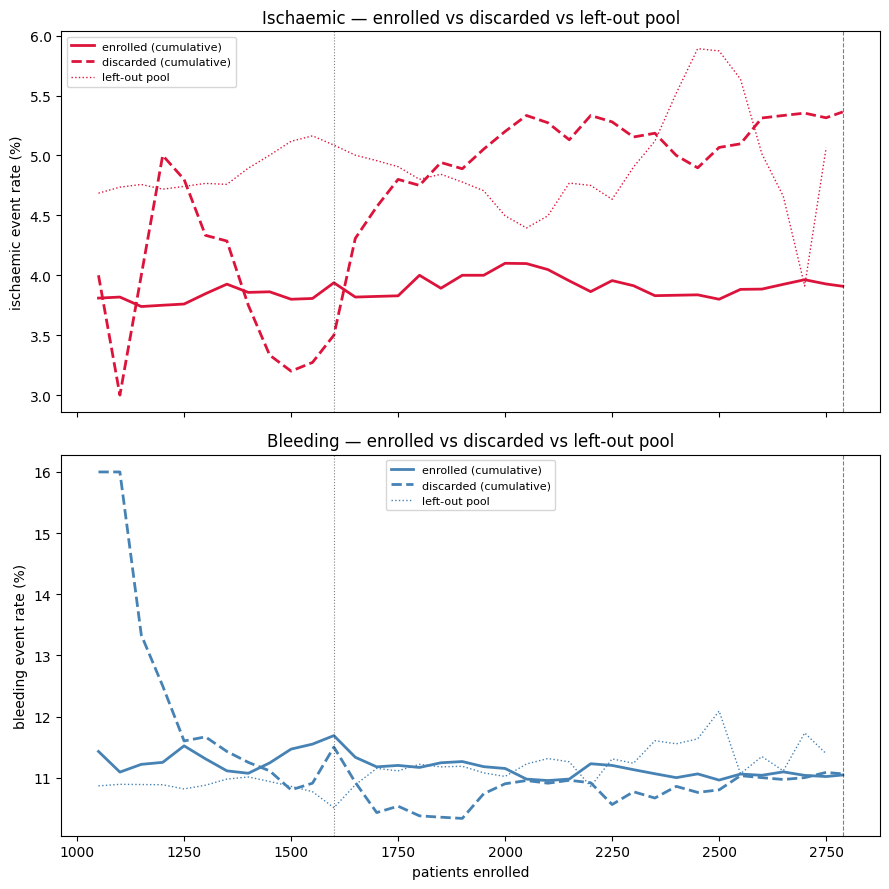

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax1.plot(hist['n'], hist['cm_isch'] * 100, color='crimson', lw=2, label='enrolled (cumulative)')
ax1.plot(hist['n'], hist['cm_discard_isch'] * 100, color='crimson', lw=2, ls='--', label='discarded (cumulative)')
ax1.plot(hist['n'], hist['leftout_isch'] * 100, color='crimson', lw=1, ls=':', label='left-out pool')
ax1.set(ylabel='ischaemic event rate (%)', title='Ischaemic — enrolled vs discarded vs left-out pool')
ax1.legend(fontsize=8)

ax2.plot(hist['n'], hist['cm_bleed'] * 100, color='steelblue', lw=2, label='enrolled (cumulative)')
ax2.plot(hist['n'], hist['cm_discard_bleed'] * 100, color='steelblue', lw=2, ls='--', label='discarded (cumulative)')
ax2.plot(hist['n'], hist['leftout_bleed'] * 100, color='steelblue', lw=1, ls=':', label='left-out pool')
ax2.set(xlabel='patients enrolled', ylabel='bleeding event rate (%)', title='Bleeding — enrolled vs discarded vs left-out pool')
ax2.legend(fontsize=8)

for ax in (ax1, ax2):
    ax.axvline(1600, color='k', lw=.8, ls=':', alpha=.5)
    ax.axvline(hist['n'].max(), color='k', lw=.8, ls='--', alpha=.5)

plt.tight_layout()
plt.show()

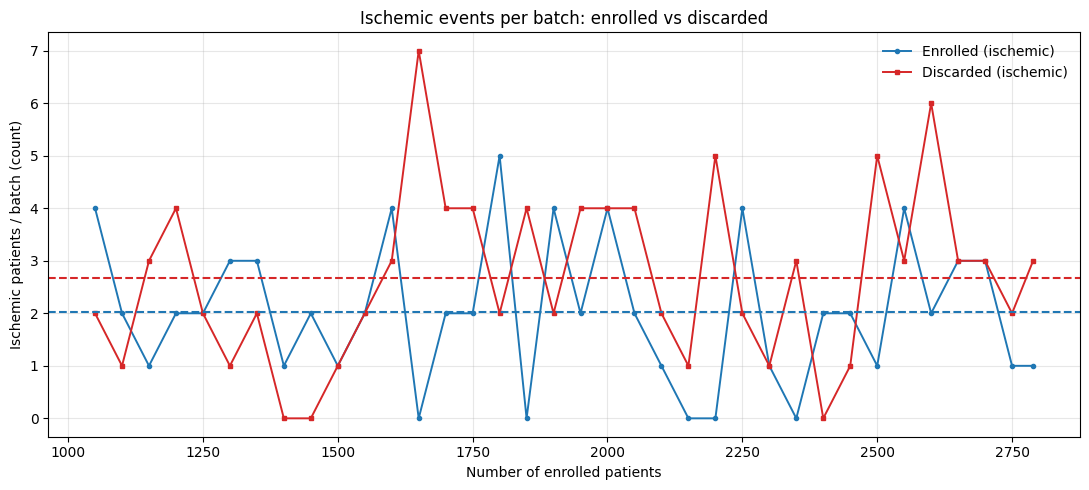

73


In [8]:
import matplotlib.pyplot as plt

x = hist['n'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, hist['batch_isch_n'],         marker='o', ms=3, lw=1.4,
        color='tab:blue', label='Enrolled (ischemic)')
ax.plot(x, hist['discard_batch_isch_n'], marker='s', ms=3, lw=1.4,
        color='tab:red',  label='Discarded (ischemic)')
ax.axhline(y=hist['batch_isch_n'].mean(), ls='--', color='tab:blue')
ax.axhline(y=hist['discard_batch_isch_n'].mean(), ls='--', color='tab:red')
ax.set_ylabel('Ischemic patients / batch (count)')
ax.set_xlabel('Number of enrolled patients')
ax.set_title('Ischemic events per batch: enrolled vs discarded')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(hist['batch_isch_n'].sum())

## Results — CATE drift vs full-cohort reference

Common-monitoring item 3: the enrolled cohort's average CATE (conflict score), evaluated
under the fixed **reference model** fit once on the whole population, plotted against the
dashed full-cohort reference line. Using the reference model (not each round's own refit)
isolates genuine population drift from refit-to-refit model noise.

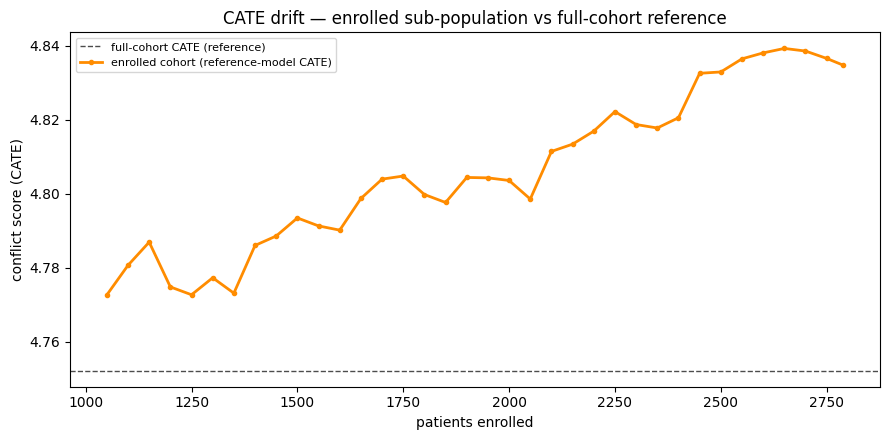

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(FULL_COHORT_CATE, color='k', lw=1, ls='--', alpha=.7, label='full-cohort CATE (reference)')
ax.plot(hist['n'], hist['cate_enrolled_ref'], color='darkorange', marker='o', ms=3, lw=2,
        label='enrolled cohort (reference-model CATE)')
ax.set(xlabel='patients enrolled', ylabel='conflict score (CATE)',
       title='CATE drift — enrolled sub-population vs full-cohort reference')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Results — AUTOC ranking quality over time

Same diagnostic as nb 03: the cross-validated AUTOC lower bound (`score_cv_autoc`, averaged
over the four endpoints), evaluated out-of-fold on the currently enrolled cohort every
`autoc_every` patients. Lower bound ~0 = no significant targeting signal; a lower bound that
climbs away from 0 as `n` grows says the sample-and-select mechanism is enrolling a
genuinely better-ranked cohort, not just changing its composition.

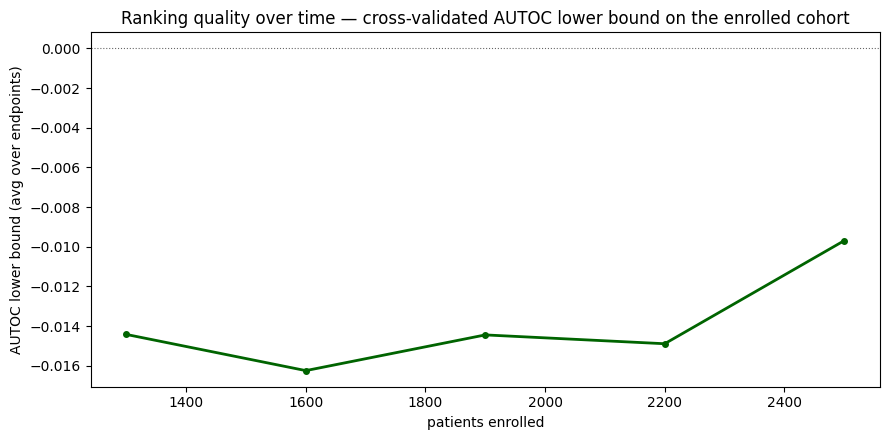

   n  autoc_lb
1300 -0.014424
1600 -0.016248
1900 -0.014447
2200 -0.014892
2500 -0.009697


In [10]:
autoc_hist = hist.dropna(subset=['autoc_lb'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='k', lw=.8, ls=':', alpha=.6)
ax.plot(autoc_hist['n'], autoc_hist['autoc_lb'], color='darkgreen', marker='o', ms=4, lw=2)
ax.set(xlabel='patients enrolled', ylabel='AUTOC lower bound (avg over endpoints)',
       title='Ranking quality over time — cross-validated AUTOC lower bound on the enrolled cohort')
plt.tight_layout()
plt.show()

print(autoc_hist[['n', 'autoc_lb']].to_string(index=False))

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


[Parallel(n_jobs=30)]: Done   3 out of  30 | elapsed:  2.8min remaining: 25.1min
[Parallel(n_jobs=30)]: Done   7 out of  30 | elapsed:  3.3min remaining: 10.8min
[Parallel(n_jobs=30)]: Done  11 out of  30 | elapsed:  3.4min remaining:  6.0min
[Parallel(n_jobs=30)]: Done  15 out of  30 | elapsed:  3.9min remaining:  3.9min
[Parallel(n_jobs=30)]: Done  19 out of  30 | elapsed:  4.4min remaining:  2.5min
[Parallel(n_jobs=30)]: Done  23 out of  30 | elapsed:  5.3min remaining:  1.6min
[Parallel(n_jobs=30)]: Done  27 out of  30 | elapsed: 10.8min remaining:  1.2min
[Parallel(n_jobs=30)]: Done  30 out of  30 | elapsed: 12.1min finished


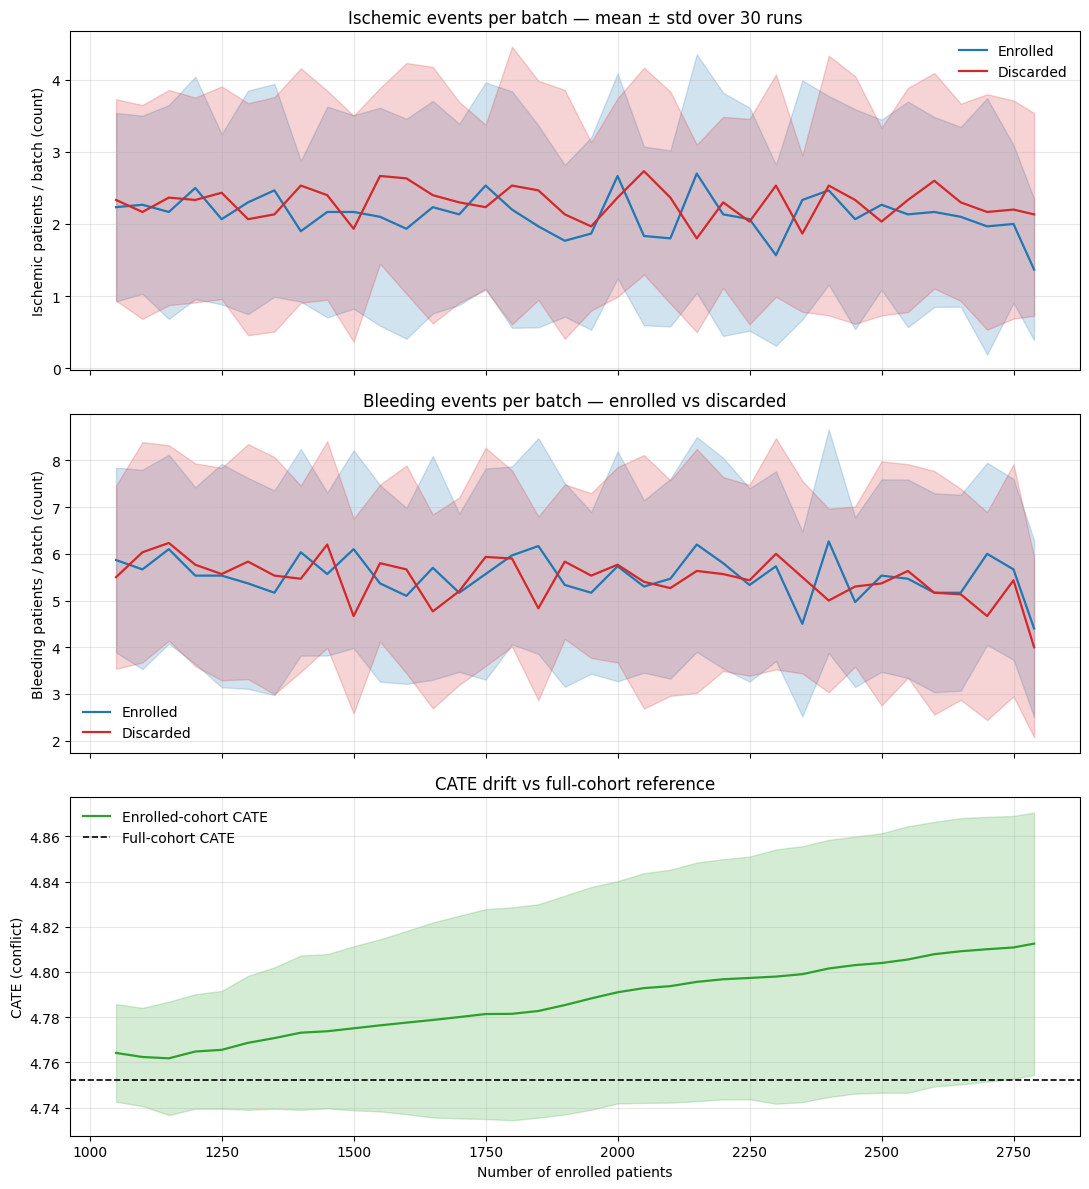

In [11]:
import os

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from joblib import Parallel, delayed

# ---------------- parameters ----------------
N_RUNS  = 30                      # number of repetitions
N_CORES = os.cpu_count() or 8
BUDGET  = max(1, round(0.75 * N_CORES))                  # keep >=75% of the machine busy
N_JOBS  = min(N_RUNS, max(1, BUDGET // 3))               # parallel processes over the seeds
FIT_N_JOBS = LGBM_N_JOBS = max(1, -(-BUDGET // N_JOBS))  # 32 workers x 5 threads = 160 cores
SEEDS   = [SEED + i for i in range(N_RUNS)]
N_SEED, SAMPLE_SIZE, N_STOP = 1000, 100, None

# ---------------- single run ----------------
def run_one(sd):
    prep = seed_fit_tune(N_SEED, seed=sd, n_trials=20, verbose=False,
                         n_jobs=FIT_N_JOBS, lgbm_n_jobs=LGBM_N_JOBS)
    _, enrolled, discarded, hist = run_sample_select_enrollment(
        prep, sample_size=SAMPLE_SIZE, c=0.0, verbose=False, N_STOP=N_STOP,
        seed=sd, autoc_every=None, tune_every=None, tune_trials=0,
        fit_n_jobs=FIT_N_JOBS, lgbm_n_jobs=LGBM_N_JOBS)
    hist = hist.copy()
    hist['run']   = sd
    hist['batch'] = np.arange(len(hist))
    return hist

# ---------------- parallel execution ----------------
results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(run_one)(sd) for sd in SEEDS)
allh = pd.concat(results, ignore_index=True)

# ---------------- aggregation per batch ----------------
g       = allh.groupby('batch')
x       = g['n'].mean().to_numpy()                       # x-axis: mean number of enrolled patients
def band(col):
    m = g[col].mean().to_numpy()
    s = g[col].std(ddof=0).to_numpy()
    return m, s

cate_full_ref = reference_conflict['conflict'].mean()    # CATE over the whole cohort

# ---------------- plots ----------------
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

# (1) ischemic per batch: enrolled vs discarded
for col, color, lab in [('batch_isch_n', 'tab:blue', 'Enrolled'),
                        ('discard_batch_isch_n', 'tab:red', 'Discarded')]:
    m, s = band(col)
    axes[0].plot(x, m, color=color, lw=1.6, label=lab)
    axes[0].fill_between(x, m - s, m + s, color=color, alpha=0.20)
axes[0].set_ylabel('Ischemic patients / batch (count)')
axes[0].set_title(f'Ischemic events per batch — mean ± std over {N_RUNS} runs')
axes[0].legend(frameon=False); axes[0].grid(alpha=0.3)

# (2) bleeding per batch: enrolled vs discarded
for col, color, lab in [('batch_bleed_n', 'tab:blue', 'Enrolled'),
                        ('discard_batch_bleed_n', 'tab:red', 'Discarded')]:
    m, s = band(col)
    axes[1].plot(x, m, color=color, lw=1.6, label=lab)
    axes[1].fill_between(x, m - s, m + s, color=color, alpha=0.20)
axes[1].set_ylabel('Bleeding patients / batch (count)')
axes[1].set_title('Bleeding events per batch — enrolled vs discarded')
axes[1].legend(frameon=False); axes[1].grid(alpha=0.3)

# (3) CATE drift on the enrolled population
m, s = band('cate_enrolled_ref')
axes[2].plot(x, m, color='tab:green', lw=1.6, label='Enrolled-cohort CATE')
axes[2].fill_between(x, m - s, m + s, color='tab:green', alpha=0.20)
axes[2].axhline(cate_full_ref, ls='--', color='k', lw=1.2, label='Full-cohort CATE')
axes[2].set_ylabel('CATE (conflict)')
axes[2].set_xlabel('Number of enrolled patients')
axes[2].set_title('CATE drift vs full-cohort reference')
axes[2].legend(frameon=False); axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Net-benefit variant — sample-and-select by trade-off instead of win-win

`acquisition_score` above ranks each random sample by `conflict` (the win-win score). This
section adds `acquisition_score_net_benefit`, reading `net_benefit_from_model` (the trade-off
score) instead, and a duplicated `run_sample_select_enrollment_net_benefit`. Same seed
(`prep`), same `sample_size`/`N_STOP`/tuning schedule as the win-win run above, so `hist` and
`hist_nb` are directly comparable batch by batch. A second reference fit
(`reference_net_benefit`) mirrors `reference_conflict` for the CATE-drift check.

In [12]:
from online_learning_utils import net_benefit_from_model

reference_net_benefit = net_benefit_from_model(reference_model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
FULL_COHORT_NET_BENEFIT = reference_net_benefit['net_benefit'].mean()
print(f'full-cohort net_benefit (trade-off score, reference model): {FULL_COHORT_NET_BENEFIT:+.4f}')


def acquisition_score_net_benefit(net_benefit, uncertainty, idx, c=1.0):
    """Same UCB1-style combination as `acquisition_score` above, but exploitation reads the
    trade-off score (`net_benefit_from_model`) instead of the win-win score
    (`conflict_from_model`)."""
    idx   = np.asarray(idx)
    value = z(net_benefit['net_benefit']).to_numpy()[idx]
    bonus = np.clip(uncertainty['uncertainty'].to_numpy()[idx], 0, None)
    return value + c * bonus


def run_sample_select_enrollment_net_benefit(prep, sample_size=100, c=0.0, verbose=True,
                                              N_STOP=None, seed=SEED,
                                              autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                                              tune_every=None, tune_trials=0,
                                              fit_n_jobs=32, lgbm_n_jobs=16):
    """Identical to `run_sample_select_enrollment` above, but ranks each random sample by
    `acquisition_score_net_benefit` (trade-off score) instead of `acquisition_score`
    (win-win score)."""
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled  = list(prep['seed_idx'])
    discarded = []
    pool      = [i for i in range(N) if i not in set(enrolled)]
    rng       = np.random.default_rng(seed)
    # Anchored to the seed size, not to 0: `enrolled` already holds len(seed_idx) patients, so
    # counting from `every` alone makes the first rounds fire back to back until the counter
    # catches up (13 firings instead of 10 at every=300, bunched at the start). "Every N new
    # patients" is what these names mean.
    next_autoc_at = None if autoc_every is None else len(enrolled) + autoc_every
    next_tune_at  = None if tune_every  is None else len(enrolled) + tune_every

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                           cf_params, nuisance_params,
                           n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)

    def rates(yy):
        if len(yy) == 0:
            return np.nan, np.nan, 0, 0
        isch  = ((yy[ENDPOINTS['death']].to_numpy()  == 1) |
                 (yy[ENDPOINTS['mi']].to_numpy()     == 1) |
                 (yy[ENDPOINTS['stroke']].to_numpy() == 1))
        bleed = yy[ENDPOINTS['bleed']].to_numpy() == 1
        return isch.mean(), bleed.mean(), int(isch.sum()), int(bleed.sum())

    hist = []
    while pool:
        if N_STOP is not None and len(enrolled) >= N_STOP:
            print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
            break

        n_sample = min(sample_size, len(pool))
        sample = rng.choice(np.asarray(pool), size=n_sample, replace=False).tolist()

        score = acquisition_score_net_benefit(net_benefit, uncertainty, sample, c=c)
        order = np.argsort(score)[::-1]
        half  = n_sample // 2
        keep_idx    = [sample[k] for k in order[:half]]
        discard_idx = [sample[k] for k in order[half:]]

        enrolled.extend(keep_idx)
        discarded.extend(discard_idx)
        pool = [p for p in pool if p not in set(sample)]

        batch_isch,   batch_bleed,   batch_isch_n,   batch_bleed_n   = rates(y.loc[keep_idx])
        dbatch_isch,  dbatch_bleed,  dbatch_isch_n,  dbatch_bleed_n  = rates(y.loc[discard_idx])
        cm_isch,      cm_bleed,      cm_isch_n,      cm_bleed_n      = rates(y[y.index.isin(enrolled)])
        cmd_isch,     cmd_bleed,     cmd_isch_n,     cmd_bleed_n     = rates(y[y.index.isin(discarded)])
        leftout_isch, leftout_bleed, leftout_isch_n, leftout_bleed_n = rates(y[y.index.isin(pool)])

        nb_enrolled_ref = reference_net_benefit['net_benefit'].iloc[enrolled].mean()

        autoc_lb = np.nan
        if autoc_every is not None and len(enrolled) >= next_autoc_at:
            with quiet_toc_warnings():   # empty top-percentile TOC groups -> NaN noise
                autoc_lb = -model.score_cv_autoc(Xn.values[enrolled], Yv[enrolled], T[enrolled],
                                                  cv=autoc_cv, z=1.0,
                                                  target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f"         AUTOC lower bound (cv={autoc_cv}, target_idx={autoc_target_idx}): {autoc_lb:+.4f}")

        hist.append(dict(
                    n=len(enrolled), n_discarded=len(discarded),
                    batch_isch=batch_isch,             batch_bleed=batch_bleed,
                    discard_batch_isch=dbatch_isch,    discard_batch_bleed=dbatch_bleed,
                    batch_isch_n=batch_isch_n,         batch_bleed_n=batch_bleed_n,
                    discard_batch_isch_n=dbatch_isch_n, discard_batch_bleed_n=dbatch_bleed_n,
                    batch_size=len(keep_idx),          discard_batch_size=len(discard_idx),
                    cm_isch=cm_isch,                   cm_bleed=cm_bleed,
                    cm_discard_isch=cmd_isch,          cm_discard_bleed=cmd_bleed,
                    cm_isch_n=cm_isch_n,               cm_discard_isch_n=cmd_isch_n,
                    leftout_isch=leftout_isch,         leftout_bleed=leftout_bleed,
                    nb_enrolled_ref=nb_enrolled_ref,
                    autoc_lb=autoc_lb,
                ))

        if verbose:
            print(f"n={len(enrolled):4d} (+{len(keep_idx)})  discarded={len(discarded):4d} (+{len(discard_idx)})  "
                  f"batch: isch={batch_isch_n} bleed={batch_bleed_n}  |  "
                  f"discard batch: isch={dbatch_isch_n} bleed={dbatch_bleed_n}  |  "
                  f"pool left={len(pool):4d}")

        if tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials,
                                                      n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                                      verbose=verbose)
            next_tune_at += tune_every
            if verbose:
                print(f"         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})")

        model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                               cf_params, nuisance_params,
                               n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, discarded, pd.DataFrame(hist)

full-cohort net_benefit (trade-off score, reference model): +4.1085


In [ ]:
model_nb, enrolled_nb, discarded_nb, hist_nb = run_sample_select_enrollment_net_benefit(
    prep, sample_size=SAMPLE_SIZE, c=0.0, verbose=True, N_STOP=N_STOP,
    autoc_every=300, tune_every=None, tune_trials=0)

print(f"net-benefit run  seed={N_SEED}  final enrolled={len(enrolled_nb)}  "
      f"final discarded={len(discarded_nb)}  batches={len(hist_nb)}")

n=1050 (+50)  discarded=  50 (+50)  batch: isch=2 bleed=5  |  discard batch: isch=4 bleed=12  |  pool left=3479
n=1100 (+50)  discarded= 100 (+50)  batch: isch=1 bleed=5  |  discard batch: isch=2 bleed=5  |  pool left=3379
n=1150 (+50)  discarded= 150 (+50)  batch: isch=2 bleed=7  |  discard batch: isch=2 bleed=4  |  pool left=3279
n=1200 (+50)  discarded= 200 (+50)  batch: isch=0 bleed=5  |  discard batch: isch=6 bleed=6  |  pool left=3179
n=1250 (+50)  discarded= 250 (+50)  batch: isch=1 bleed=7  |  discard batch: isch=3 bleed=6  |  pool left=3079
         AUTOC lower bound (cv=3, target_idx=None): -0.0153
n=1300 (+50)  discarded= 300 (+50)  batch: isch=2 bleed=5  |  discard batch: isch=2 bleed=4  |  pool left=2979
n=1350 (+50)  discarded= 350 (+50)  batch: isch=4 bleed=5  |  discard batch: isch=1 bleed=3  |  pool left=2879
n=1400 (+50)  discarded= 400 (+50)  batch: isch=0 bleed=4  |  discard batch: isch=1 bleed=6  |  pool left=2779
n=1450 (+50)  discarded= 450 (+50)  batch: isch=1 b

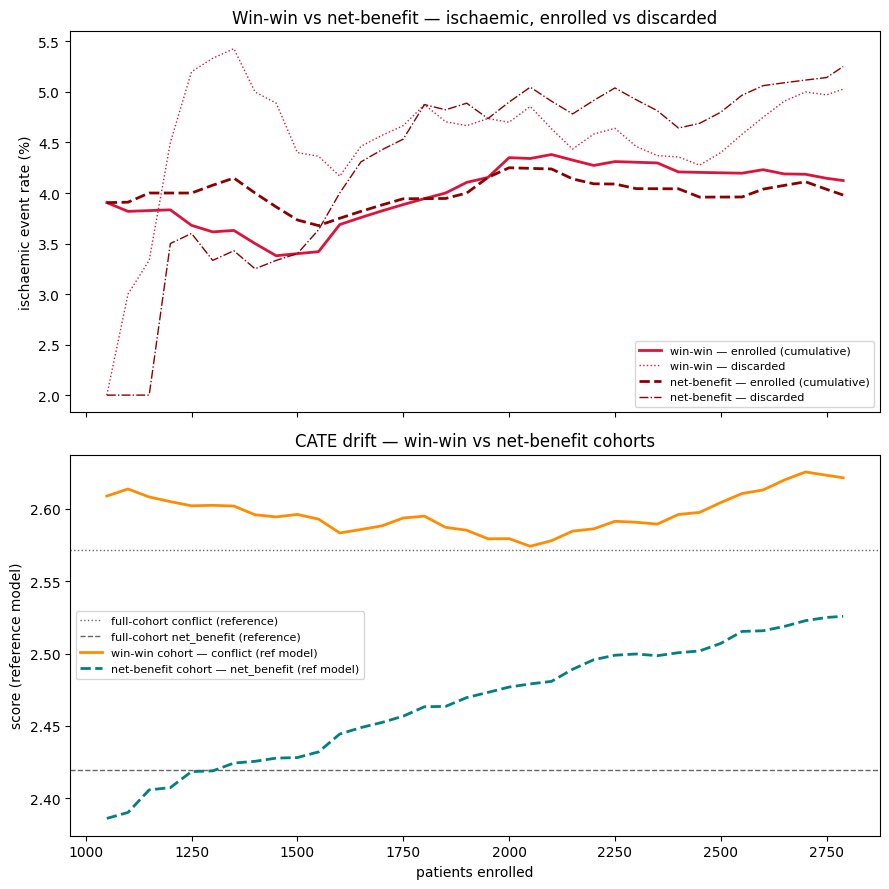

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax1.plot(hist['n'], hist['cm_isch'] * 100, color='crimson', lw=2, label='win-win — enrolled (cumulative)')
ax1.plot(hist['n'], hist['cm_discard_isch'] * 100, color='crimson', lw=1, ls=':', label='win-win — discarded')
ax1.plot(hist_nb['n'], hist_nb['cm_isch'] * 100, color='darkred', lw=2, ls='--', label='net-benefit — enrolled (cumulative)')
ax1.plot(hist_nb['n'], hist_nb['cm_discard_isch'] * 100, color='darkred', lw=1, ls='-.', label='net-benefit — discarded')
ax1.set(ylabel='ischaemic event rate (%)', title='Win-win vs net-benefit — ischaemic, enrolled vs discarded')
ax1.legend(fontsize=8)

ax2.axhline(FULL_COHORT_CATE, color='k', lw=1, ls=':', alpha=.6, label='full-cohort conflict (reference)')
ax2.axhline(FULL_COHORT_NET_BENEFIT, color='k', lw=1, ls='--', alpha=.6, label='full-cohort net_benefit (reference)')
ax2.plot(hist['n'], hist['cate_enrolled_ref'], color='darkorange', lw=2, label='win-win cohort — conflict (ref model)')
ax2.plot(hist_nb['n'], hist_nb['nb_enrolled_ref'], color='teal', lw=2, ls='--', label='net-benefit cohort — net_benefit (ref model)')
ax2.set(xlabel='patients enrolled', ylabel='score (reference model)', title='CATE drift — win-win vs net-benefit cohorts')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x = hist_nb['n'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, hist_nb['batch_isch_n'],         marker='o', ms=3, lw=1.4,
        color='tab:blue', label='Enrolled (ischemic)')
ax.plot(x, hist_nb['discard_batch_isch_n'], marker='s', ms=3, lw=1.4,
        color='tab:red',  label='Discarded (ischemic)')
ax.axhline(y=hist_nb['batch_isch_n'].mean(), ls='--', color='tab:blue')
ax.axhline(y=hist_nb['discard_batch_isch_n'].mean(), ls='--', color='tab:red')
ax.set_ylabel('Ischemic patients / batch (count)')
ax.set_xlabel('Number of enrolled patients')
ax.set_title('Ischemic events per batch: enrolled vs discarded (net-benefit run)')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(hist_nb['batch_isch_n'].sum(), hist_nb['discard_batch_isch_n'].sum())

## Angle-scalarised variant — sample-and-select by the win-win diagonal instead of the linear sum

`acquisition_score` above ranks each random sample by `conflict['conflict']`
(`bleed + weighted_isch`), which correlates rho=+0.91 with bleed alone on this cohort (only
+0.44 with the ischaemic side) -- so the "win-win" cohort it selects is mostly a
bleeding-benefit cohort: its top-1500 on the tuned forest are only 58% actual win-win
patients (`bleed`>0 **and** ischaemic benefit>0), not the ~100% the name implies. This
section adds `acquisition_score_angle` (`online_learning_utils.py`), the whole-sample
ranking that exactly reproduces `duel_by_angle`'s pairwise win-win-diagonal geometry (keep
the win-win quadrant over everything else, unconditionally -- verified to reproduce
`duel_by_angle`'s winner on 100% of 50,000 random pairs on this cohort), and a duplicated
`run_sample_select_enrollment_angle`. Same seed (`prep`), same
`sample_size`/`N_STOP`/tuning schedule as the runs above. In place of the CATE-drift check
(the angle score is a tiered rank, not a CATE in natural units), this tracks the fraction of
the enrolled cohort that the fixed **reference** model actually places in the win-win
quadrant -- the diagnostic the linear sum was supposed to guarantee and, on this cohort,
does not.

In [ ]:
from online_learning_utils import acquisition_score_angle

reference_x = reference_conflict['bleed'].to_numpy()
reference_y = weighted_isch({k: reference_conflict[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS).to_numpy()
FULL_COHORT_Q1_FRAC = float(((reference_x > 0) & (reference_y > 0)).mean())
print(f'full-cohort win-win (Q1) fraction, reference model: {FULL_COHORT_Q1_FRAC:.1%}')


def run_sample_select_enrollment_angle(prep, sample_size=100, c=0.0, verbose=True,
                                        N_STOP=None, seed=SEED,
                                        autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                                        tune_every=None, tune_trials=0,
                                        fit_n_jobs=32, lgbm_n_jobs=16):
    """Identical to `run_sample_select_enrollment` above, but ranks each random sample by
    `acquisition_score_angle` (duel_by_angle's win-win-diagonal geometry) instead of
    `acquisition_score` (the bleed-dominated linear sum)."""
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled  = list(prep['seed_idx'])
    discarded = []
    pool      = [i for i in range(N) if i not in set(enrolled)]
    rng       = np.random.default_rng(seed)
    # Anchored to the seed size, not to 0: `enrolled` already holds len(seed_idx) patients, so
    # counting from `every` alone makes the first rounds fire back to back until the counter
    # catches up (13 firings instead of 10 at every=300, bunched at the start). "Every N new
    # patients" is what these names mean.
    next_autoc_at = None if autoc_every is None else len(enrolled) + autoc_every
    next_tune_at  = None if tune_every  is None else len(enrolled) + tune_every

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                           cf_params, nuisance_params,
                           n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)

    def rates(yy):
        if len(yy) == 0:
            return np.nan, np.nan, 0, 0
        isch  = ((yy[ENDPOINTS['death']].to_numpy()  == 1) |
                 (yy[ENDPOINTS['mi']].to_numpy()     == 1) |
                 (yy[ENDPOINTS['stroke']].to_numpy() == 1))
        bleed = yy[ENDPOINTS['bleed']].to_numpy() == 1
        return isch.mean(), bleed.mean(), int(isch.sum()), int(bleed.sum())

    hist = []
    while pool:
        if N_STOP is not None and len(enrolled) >= N_STOP:
            print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
            break

        n_sample = min(sample_size, len(pool))
        sample = rng.choice(np.asarray(pool), size=n_sample, replace=False).tolist()

        score = acquisition_score_angle(conflict, uncertainty, sample, ISCH_WEIGHTS, c=c)
        order = np.argsort(score)[::-1]
        half  = n_sample // 2
        keep_idx    = [sample[k] for k in order[:half]]
        discard_idx = [sample[k] for k in order[half:]]

        enrolled.extend(keep_idx)
        discarded.extend(discard_idx)
        pool = [p for p in pool if p not in set(sample)]

        batch_isch,   batch_bleed,   batch_isch_n,   batch_bleed_n   = rates(y.loc[keep_idx])
        dbatch_isch,  dbatch_bleed,  dbatch_isch_n,  dbatch_bleed_n  = rates(y.loc[discard_idx])
        cm_isch,      cm_bleed,      cm_isch_n,      cm_bleed_n      = rates(y[y.index.isin(enrolled)])
        cmd_isch,     cmd_bleed,     cmd_isch_n,     cmd_bleed_n     = rates(y[y.index.isin(discarded)])
        leftout_isch, leftout_bleed, leftout_isch_n, leftout_bleed_n = rates(y[y.index.isin(pool)])

        enrolled_arr      = np.asarray(enrolled)
        angle_q1_frac_ref = float(((reference_x[enrolled_arr] > 0) & (reference_y[enrolled_arr] > 0)).mean())

        autoc_lb = np.nan
        if autoc_every is not None and len(enrolled) >= next_autoc_at:
            with quiet_toc_warnings():   # empty top-percentile TOC groups -> NaN noise
                autoc_lb = -model.score_cv_autoc(Xn.values[enrolled], Yv[enrolled], T[enrolled],
                                                  cv=autoc_cv, z=1.0,
                                                  target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f"         AUTOC lower bound (cv={autoc_cv}, target_idx={autoc_target_idx}): {autoc_lb:+.4f}")

        hist.append(dict(
                    n=len(enrolled), n_discarded=len(discarded),
                    batch_isch=batch_isch,             batch_bleed=batch_bleed,
                    discard_batch_isch=dbatch_isch,    discard_batch_bleed=dbatch_bleed,
                    batch_isch_n=batch_isch_n,         batch_bleed_n=batch_bleed_n,
                    discard_batch_isch_n=dbatch_isch_n, discard_batch_bleed_n=dbatch_bleed_n,
                    batch_size=len(keep_idx),          discard_batch_size=len(discard_idx),
                    cm_isch=cm_isch,                   cm_bleed=cm_bleed,
                    cm_discard_isch=cmd_isch,          cm_discard_bleed=cmd_bleed,
                    cm_isch_n=cm_isch_n,               cm_discard_isch_n=cmd_isch_n,
                    leftout_isch=leftout_isch,         leftout_bleed=leftout_bleed,
                    angle_q1_frac_ref=angle_q1_frac_ref,
                    autoc_lb=autoc_lb,
                ))

        if verbose:
            print(f"n={len(enrolled):4d} (+{len(keep_idx)})  discarded={len(discarded):4d} (+{len(discard_idx)})  "
                  f"batch: isch={batch_isch_n} bleed={batch_bleed_n}  |  "
                  f"discard batch: isch={dbatch_isch_n} bleed={dbatch_bleed_n}  |  "
                  f"pool left={len(pool):4d}")

        if tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials,
                                                      n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs,
                                                      verbose=verbose)
            next_tune_at += tune_every
            if verbose:
                print(f"         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})")

        model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline,
                               cf_params, nuisance_params,
                               n_jobs=fit_n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, discarded, pd.DataFrame(hist)

full-cohort win-win (Q1) fraction, reference model: 50.7%


In [ ]:
model_angle, enrolled_angle, discarded_angle, hist_angle = run_sample_select_enrollment_angle(
    prep, sample_size=SAMPLE_SIZE, c=0.0, verbose=True, N_STOP=N_STOP,
    autoc_every=300, tune_every=None, tune_trials=0)

print(f"angle-scalarised run  seed={N_SEED}  final enrolled={len(enrolled_angle)}  "
      f"final discarded={len(discarded_angle)}  batches={len(hist_angle)}")

         AUTOC lower bound (cv=3, target_idx=None): +0.0000
n=1050 (+50)  discarded=  50 (+50)  batch: isch=5 bleed=8  |  discard batch: isch=1 bleed=9  |  pool left=3479
         Re-tuned hyperparameters at n=1050 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0247
n=1100 (+50)  discarded= 100 (+50)  batch: isch=2 bleed=6  |  discard batch: isch=1 bleed=4  |  pool left=3379
         Re-tuned hyperparameters at n=1100 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0217
n=1150 (+50)  discarded= 150 (+50)  batch: isch=3 bleed=7  |  discard batch: isch=1 bleed=4  |  pool left=3279
         Re-tuned hyperparameters at n=1150 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0202
n=1200 (+50)  discarded= 200 (+50)  batch: isch=2 bleed=9  |  discard batch: isch=4 bleed=2  |  pool left=3179
         Re-tuned hyperparameters at n=1200 (n_trials=0)
n=1250 (+50)  discarded= 250 (+50)  batch: isch=2 bleed=5  |  discard batch: isch=2 blee

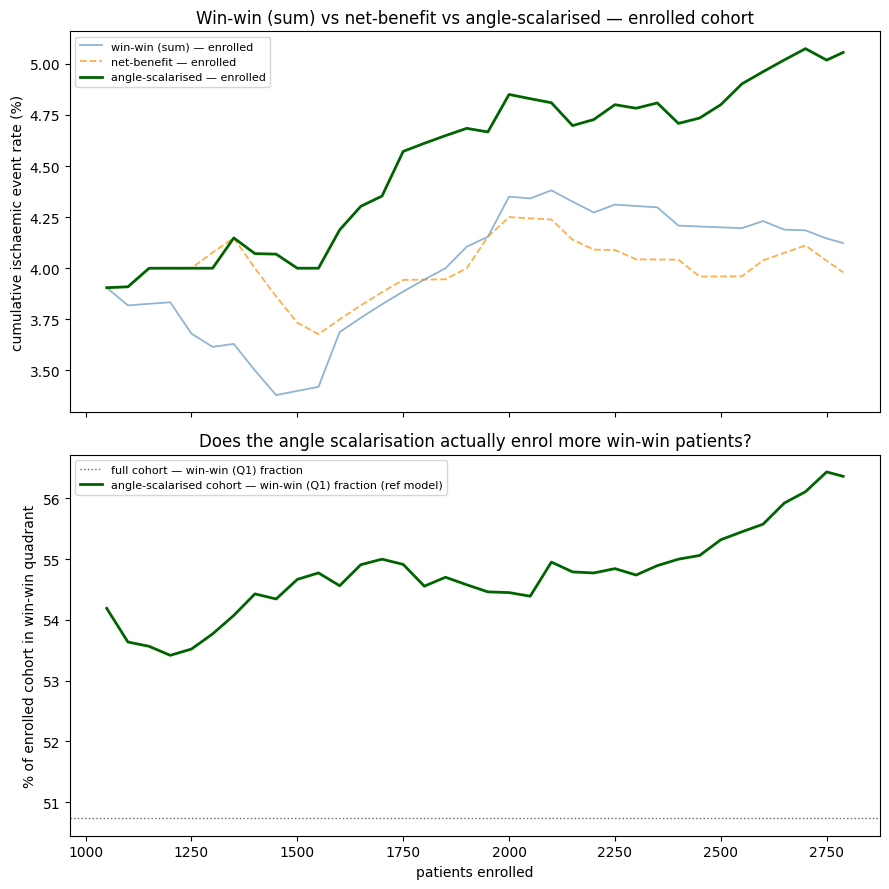

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax1.plot(hist['n'], hist['cm_isch'] * 100, color='steelblue', lw=1.3, alpha=.6, label='win-win (sum) — enrolled')
ax1.plot(hist_nb['n'], hist_nb['cm_isch'] * 100, color='darkorange', lw=1.3, ls='--', alpha=.7, label='net-benefit — enrolled')
ax1.plot(hist_angle['n'], hist_angle['cm_isch'] * 100, color='darkgreen', lw=2, label='angle-scalarised — enrolled')
ax1.set(ylabel='cumulative ischaemic event rate (%)',
        title='Win-win (sum) vs net-benefit vs angle-scalarised — enrolled cohort')
ax1.legend(fontsize=8)

ax2.axhline(FULL_COHORT_Q1_FRAC * 100, color='k', lw=1, ls=':', alpha=.6, label='full cohort — win-win (Q1) fraction')
ax2.plot(hist_angle['n'], hist_angle['angle_q1_frac_ref'] * 100, color='darkgreen', lw=2,
         label='angle-scalarised cohort — win-win (Q1) fraction (ref model)')
ax2.set(xlabel='patients enrolled', ylabel='% of enrolled cohort in win-win quadrant',
        title='Does the angle scalarisation actually enrol more win-win patients?')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

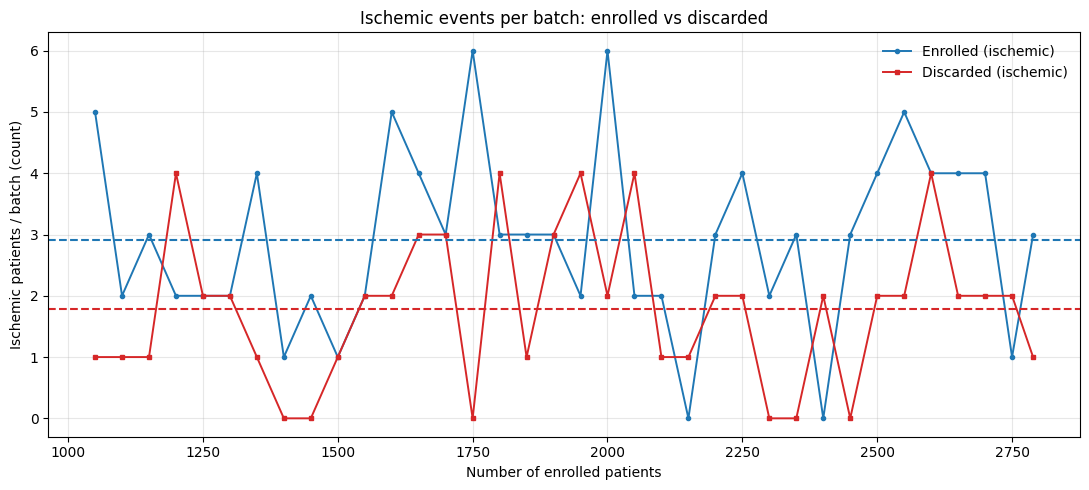

105 64


In [ ]:
import matplotlib.pyplot as plt

x = hist_angle['n'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, hist_angle['batch_isch_n'],         marker='o', ms=3, lw=1.4,
        color='tab:blue', label='Enrolled (ischemic)')
ax.plot(x, hist_angle['discard_batch_isch_n'], marker='s', ms=3, lw=1.4,
        color='tab:red',  label='Discarded (ischemic)')
ax.axhline(y=hist_angle['batch_isch_n'].mean(), ls='--', color='tab:blue')
ax.axhline(y=hist_angle['discard_batch_isch_n'].mean(), ls='--', color='tab:red')
ax.set_ylabel('Ischemic patients / batch (count)')
ax.set_xlabel('Number of enrolled patients')
ax.set_title('Ischemic events per batch: enrolled vs discarded')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(hist_angle['batch_isch_n'].sum(), hist_angle['discard_batch_isch_n'].sum())